# Agentic Market Mix Modeling (MMM) — Prototype

End-to-end pipeline: data ingestion → feature engineering → causal discovery → Bayesian MMM → hyperparameter tuning → budget optimization → counterfactual simulation.

In [1]:
# ── 0. Imports ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

---
## 1. Data Ingestion

Load the marketing dataset and do a quick sanity check.

In [2]:
# ── 1. Load data ────────────────────────────────────────────────
df = pd.read_csv("mmm_dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
df.head(10)

Shape: (100, 8)

Column types:
week                  int64
tv_spend            float64
google_ads_spend    float64
meta_ads_spend      float64
influencer_spend    float64
discount              int64
seasonality         float64
sales               float64
dtype: object


,week,tv_spend,google_ads_spend,meta_ads_spend,influencer_spend,discount,seasonality,sales
0,1,13119.94,5314.29,7494.22,1206.73,0,1.000,12441.66
1,2,19457.86,11364.10,3588.98,3125.42,5,1.024,19099.76
2,3,17051.93,8143.56,4131.40,3162.54,0,1.048,15368.53
3,4,15585.24,10085.71,9289.88,3549.72,0,1.071,14851.47
4,5,10716.21,14075.66,7245.00,3904.37,5,1.093,16066.88
5,6,10715.94,7492.92,3064.38,4903.41,15,1.114,13212.90
6,7,9638.92,9103.83,3710.30,3065.20,15,1.133,15424.01
7,8,18527.94,12555.51,7644.51,2291.83,0,1.150,16070.28
8,9,15612.27,7287.98,3035.43,4180.74,5,1.165,15156.48
9,10,16788.80,5769.80,4125.66,2083.33,0,1.177,11585.25


In [3]:
# quick summary stats
df.describe().round(2)

,week,tv_spend,google_ads_spend,meta_ads_spend,influencer_spend,discount,seasonality,sales
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,50.50,14171.99,9978.32,6623.21,2964.60,6.85,1.00,15319.29
std,29.01,3272.38,2931.11,2053.98,1173.81,5.76,0.14,2669.86
min,1.00,9060.74,5069.52,3035.43,1057.57,0.00,0.80,8195.17
25%,25.75,11125.21,7420.04,4938.16,1998.46,0.00,0.85,13528.48
50%,50.50,14105.56,10056.25,6937.88,3038.88,5.00,1.01,15745.54
75%,75.25,17032.24,12661.84,8266.57,3943.11,10.00,1.15,17127.53
max,100.00,19855.76,14856.50,9930.38,4962.02,15.00,1.20,20383.20


In [4]:
# check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
week                0
tv_spend            0
google_ads_spend    0
meta_ads_spend      0
influencer_spend    0
discount            0
seasonality         0
sales               0
dtype: int64

Duplicate rows: 0


---
## 2. Data Processing & Feature Engineering

### 2a. Exploratory plots

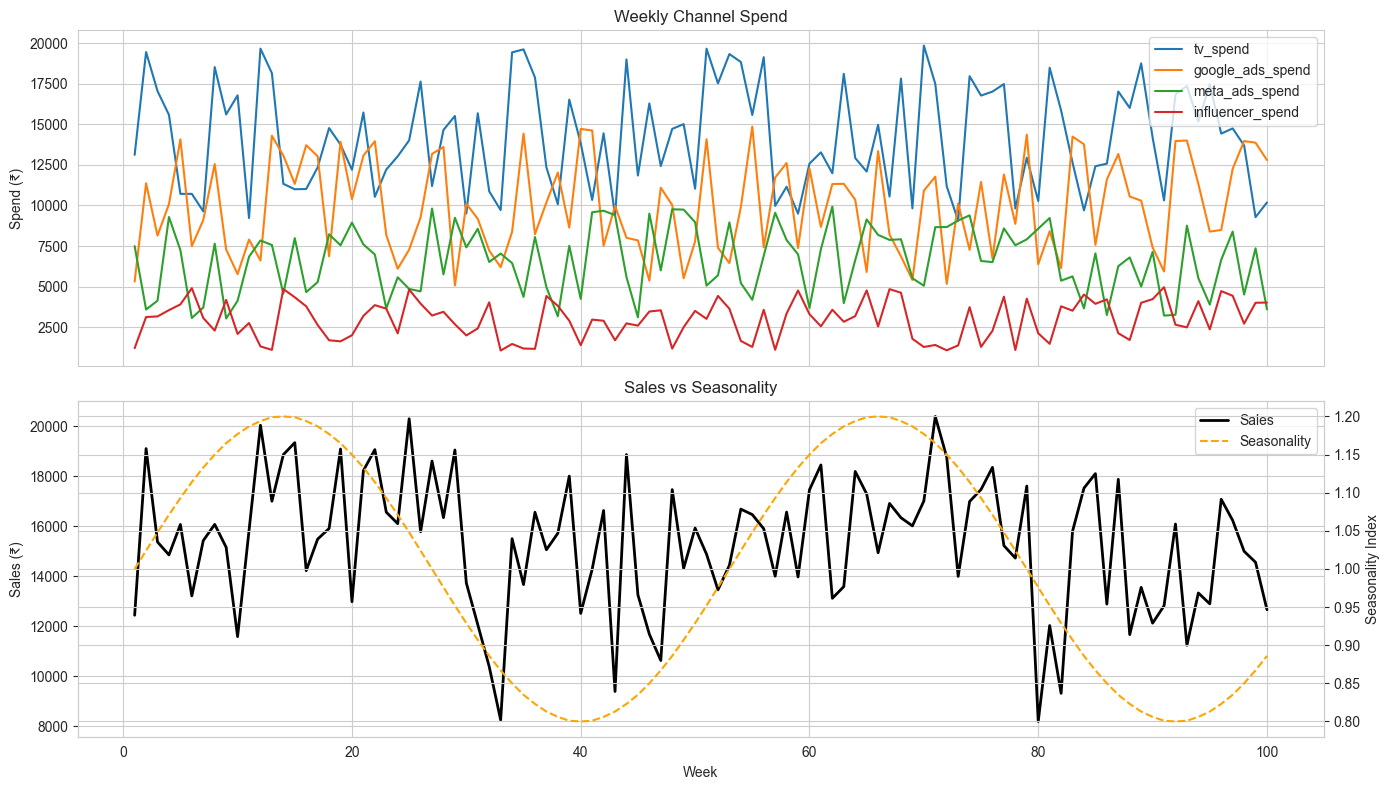

In [5]:
# ── 2a. Time-series overview ────────────────────────────────────
spend_cols = ["tv_spend", "google_ads_spend", "meta_ads_spend", "influencer_spend"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# channel spend over time
for col in spend_cols:
    axes[0].plot(df["week"], df[col], label=col)
axes[0].set_ylabel("Spend (₹)")
axes[0].set_title("Weekly Channel Spend")
axes[0].legend()

# sales + seasonality overlay
ax1 = axes[1]
ax1.plot(df["week"], df["sales"], color="black", linewidth=2, label="Sales")
ax1.set_ylabel("Sales (₹)")
ax1.set_xlabel("Week")

ax2 = ax1.twinx()
ax2.plot(df["week"], df["seasonality"], color="orange", linestyle="--", label="Seasonality")
ax2.set_ylabel("Seasonality Index")

ax1.set_title("Sales vs Seasonality")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

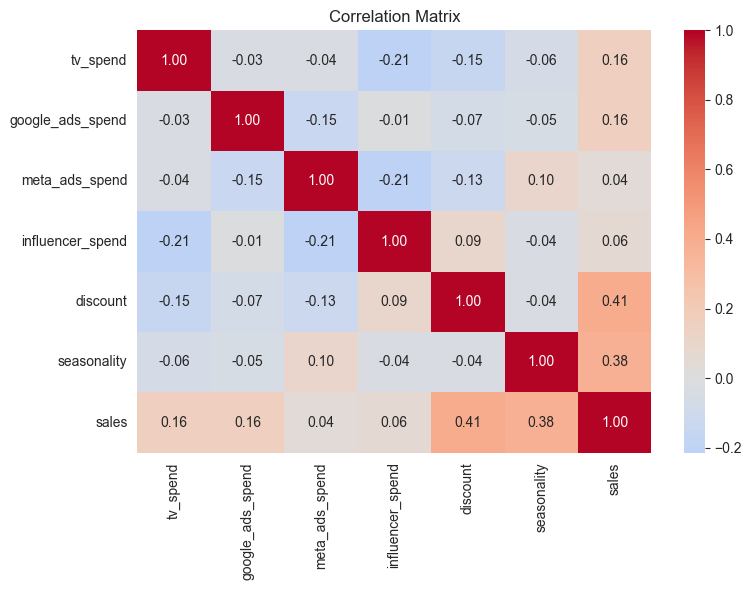

In [6]:
# correlation heatmap
corr = df[spend_cols + ["discount", "seasonality", "sales"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 2b. Adstock Transformation

Models the **carry-over effect** of advertising — today's ad still has impact next week.

$$\text{adstock}_t = x_t + \lambda \cdot \text{adstock}_{t-1}$$

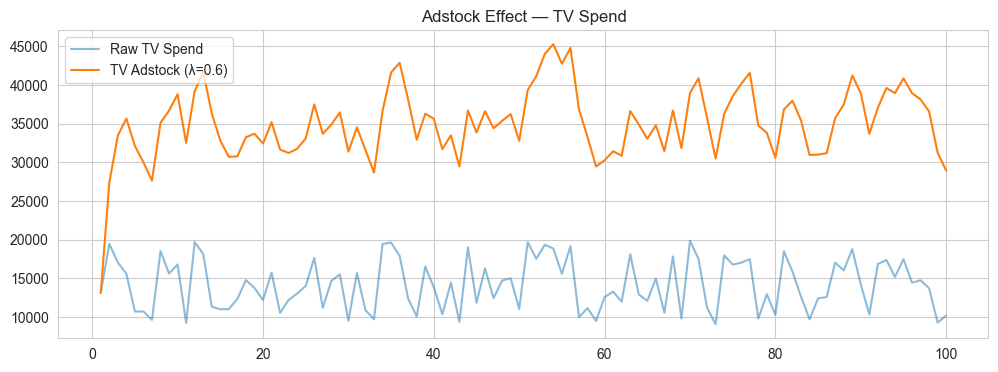

In [7]:
# ── 2b. Adstock transformation ──────────────────────────────────
def adstock_transform(series, decay=0.5):
    """Geometric adstock / carry-over decay."""
    adstocked = np.zeros(len(series))
    adstocked[0] = series.iloc[0]
    for i in range(1, len(series)):
        adstocked[i] = series.iloc[i] + decay * adstocked[i - 1]
    return adstocked

# default decay per channel (we'll optimise these later with Optuna)
default_decays = {
    "tv_spend": 0.6,
    "google_ads_spend": 0.3,
    "meta_ads_spend": 0.4,
    "influencer_spend": 0.5,
}

for col, decay in default_decays.items():
    df[f"{col}_adstock"] = adstock_transform(df[col], decay)

# peek at the effect on TV
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["week"], df["tv_spend"], alpha=0.5, label="Raw TV Spend")
ax.plot(df["week"], df["tv_spend_adstock"], label="TV Adstock (λ=0.6)")
ax.set_title("Adstock Effect — TV Spend")
ax.legend()
plt.show()

### 2c. Saturation (Diminishing Returns)

At some point, more money into a channel yields less incremental return.

$$\text{saturated} = 1 - e^{-\alpha \cdot x}$$

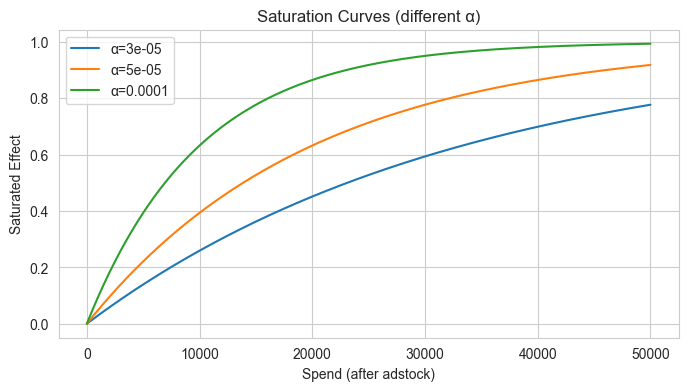

In [8]:
# ── 2c. Saturation transformation ───────────────────────────────
def saturation_transform(series, alpha=0.0001):
    """Exponential saturation / diminishing returns curve."""
    return 1 - np.exp(-alpha * series)

# apply to adstocked spend
adstock_cols = [c for c in df.columns if c.endswith("_adstock")]
for col in adstock_cols:
    sat_col = col.replace("_adstock", "_saturated")
    df[sat_col] = saturation_transform(df[col], alpha=0.00005)

# visualise the curve shape at different alphas
x_range = np.linspace(0, 50000, 500)
plt.figure(figsize=(8, 4))
for a in [0.00003, 0.00005, 0.0001]:
    plt.plot(x_range, 1 - np.exp(-a * x_range), label=f"α={a}")
plt.xlabel("Spend (after adstock)")
plt.ylabel("Saturated Effect")
plt.title("Saturation Curves (different α)")
plt.legend()
plt.show()

In [9]:
# final feature matrix preview
feature_cols = [c for c in df.columns if c.endswith("_saturated")] + ["discount", "seasonality"]
print("Model features:", feature_cols)
df[["week"] + feature_cols + ["sales"]].head(10)

Model features: ['tv_spend_saturated', 'google_ads_spend_saturated', 'meta_ads_spend_saturated', 'influencer_spend_saturated', 'discount', 'seasonality']


,week,tv_spend_saturated,google_ads_spend_saturated,meta_ads_spend_saturated,influencer_spend_saturated,discount,seasonality,sales
0,1,0.481076,0.233342,0.312512,0.058552,0,1.000,12441.66
1,2,0.745000,0.476867,0.280597,0.170091,5,1.024,19099.76
2,3,0.812221,0.452040,0.287021,0.222247,0,1.048,15368.53
3,4,0.831826,0.495785,0.451087,0.261519,0,1.071,14851.47
4,5,0.799204,0.597157,0.452381,0.293052,5,1.093,16066.88
5,6,0.776664,0.476600,0.325706,0.342013,15,1.114,13212.90
6,7,0.748771,0.477648,0.290469,0.304097,15,1.133,15424.01
7,8,0.827133,0.560712,0.405174,0.256111,0,1.150,16070.28
8,9,0.840187,0.457289,0.302021,0.300206,5,1.165,15156.48
9,10,0.856252,0.376149,0.295389,0.246217,0,1.177,11585.25


---
## 3. Causal Discovery Layer

Use **DoWhy** to check whether a channel spend *actually* causes sales (not just correlation).

We build a causal graph from domain knowledge, identify the effect, and run refutation tests.

In [10]:
# ── 3. Causal discovery with DoWhy ──────────────────────────────
from dowhy import CausalModel

# domain-knowledge DAG
# seasonality confounds both spend decisions and sales
causal_graph = """
digraph {
    tv_spend_saturated -> sales;
    google_ads_spend_saturated -> sales;
    meta_ads_spend_saturated -> sales;
    influencer_spend_saturated -> sales;
    discount -> sales;
    seasonality -> sales;
    seasonality -> tv_spend_saturated;
    seasonality -> google_ads_spend_saturated;
}
"""

model_dowhy = CausalModel(
    data=df,
    treatment="google_ads_spend_saturated",
    outcome="sales",
    graph=causal_graph,
)

identified = model_dowhy.identify_effect()
print(identified)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
              d                                    
─────────────────────────────(E[sales|seasonality])
d[google_ads_spend_saturated]                      
Estimand assumption 1, Unconfoundedness: If U→{google_ads_spend_saturated} and U→sales then P(sales|google_ads_spend_saturated,seasonality,U) = P(sales|google_ads_spend_saturated,seasonality)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
              d                                    
─────────────────────────────(E[sales|seasonality])
d[google_ads_spend_saturated]                      
Estimand assumption 1, Unconfoundedness: If U→{google_ads_spend_saturated} and U→sales then P(sales|google_ads_spend_saturated,seasonality,U) = P(sales|google_ads_spend_saturated,se

In [11]:
# estimate causal effect of Google Ads on Sales
estimate = model_dowhy.estimate_effect(
    identified,
    method_name="backdoor.linear_regression",
)
print(f"Causal estimate (Google Ads → Sales): {estimate.value:.2f}")
print(estimate)

Causal estimate (Google Ads → Sales): 6142.96
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
              d                                    
─────────────────────────────(E[sales|seasonality])
d[google_ads_spend_saturated]                      
Estimand assumption 1, Unconfoundedness: If U→{google_ads_spend_saturated} and U→sales then P(sales|google_ads_spend_saturated,seasonality,U) = P(sales|google_ads_spend_saturated,seasonality)

## Realized estimand
b: sales~google_ads_spend_saturated+seasonality+google_ads_spend_saturated*discount+google_ads_spend_saturated*meta_ads_spend_saturated+google_ads_spend_saturated*tv_spend_saturated+google_ads_spend_saturated*influencer_spend_saturated
Target units: 

## Estimate
Mean value: 6142.957939743774
### Conditional Estimates
__categorical__discount  __categorical__meta_ads_spend_saturated  __categorical__tv_spend_saturated  __cate

In [12]:
# refutation: add random common cause — if estimate barely changes, it's robust
refutation = model_dowhy.refute_estimate(
    identified,
    estimate,
    method_name="random_common_cause",
    num_simulations=50,
)
print(refutation)

Refute: Add a random common cause
Estimated effect:6142.957939743774
New effect:6166.979068176812
p value:0.47127381454317885



                            causal_effect
tv_spend_saturated                9166.83
google_ads_spend_saturated        6142.96
discount                           201.90
meta_ads_spend_saturated           -61.85
influencer_spend_saturated        -700.23


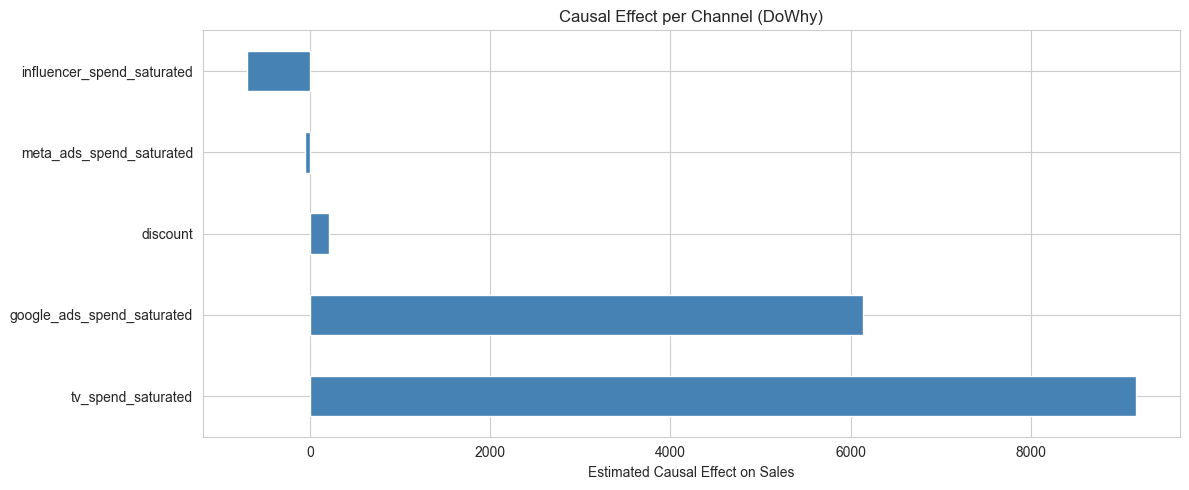

In [13]:
# causal effects for ALL channels
treatments = [
    "tv_spend_saturated",
    "google_ads_spend_saturated",
    "meta_ads_spend_saturated",
    "influencer_spend_saturated",
    "discount",
]

causal_effects = {}
for t in treatments:
    m = CausalModel(data=df, treatment=t, outcome="sales", graph=causal_graph)
    ident = m.identify_effect()
    est = m.estimate_effect(ident, method_name="backdoor.linear_regression")
    causal_effects[t] = est.value

causal_df = pd.DataFrame.from_dict(causal_effects, orient="index", columns=["causal_effect"])
causal_df = causal_df.sort_values("causal_effect", ascending=False)
print(causal_df.round(2))

causal_df.plot.barh(legend=False, color="steelblue")
plt.xlabel("Estimated Causal Effect on Sales")
plt.title("Causal Effect per Channel (DoWhy)")
plt.tight_layout()
plt.show()

---
## 4. Market Mix Modeling — Bayesian Regression (PyMC)

$$\text{sales}_t = \alpha + \sum_i \beta_i \cdot x_{i,t} + \epsilon_t$$

PyMC gives posterior distributions → uncertainty-aware channel contributions.

In [14]:
# ── 4. Bayesian MMM with PyMC ──────────────────────────────────
import pymc as pm
import arviz as az

feature_names = [
    "tv_spend_saturated",
    "google_ads_spend_saturated",
    "meta_ads_spend_saturated",
    "influencer_spend_saturated",
    "discount",
    "seasonality",
]

X = df[feature_names].values
y = df["sales"].values

# standardize for better MCMC sampling
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

print(f"Features: {feature_names}")
print(f"X shape: {X_scaled.shape}, y shape: {y_scaled.shape}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Features: ['tv_spend_saturated', 'google_ads_spend_saturated', 'meta_ads_spend_saturated', 'influencer_spend_saturated', 'discount', 'seasonality']
X shape: (100, 6), y shape: (100,)


In [15]:
# sample the Bayesian model
with pm.Model() as mmm_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    betas = pm.Normal("betas", mu=0, sigma=1, shape=len(feature_names))
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = alpha + pm.math.dot(X_scaled, betas)
    likelihood = pm.Normal("sales", mu=mu, sigma=sigma, observed=y_scaled)

    trace = pm.sample(1000, tune=1000, cores=1, random_seed=42, progressbar=True)

print("Sampling complete!")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, betas, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 124 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling complete!


In [16]:
# posterior summary table
summary = az.summary(trace, var_names=["betas", "alpha", "sigma"])
summary.index = [f"beta_{n}" for n in feature_names] + ["alpha", "sigma"]
summary.round(3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_tv_spend_saturated,0.143,0.087,-0.012,0.306,0.002,0.002,2502.0,1649.0,1.0
beta_google_ads_spend_saturated,0.176,0.087,0.018,0.346,0.002,0.002,1911.0,1480.0,1.0
beta_meta_ads_spend_saturated,-0.035,0.087,-0.188,0.136,0.002,0.002,2172.0,1636.0,1.0
beta_influencer_spend_saturated,-0.074,0.089,-0.227,0.095,0.002,0.002,2442.0,1698.0,1.0
beta_discount,0.421,0.084,0.277,0.590,0.002,0.002,2957.0,1655.0,1.0
beta_seasonality,0.419,0.080,0.281,0.577,0.002,0.002,2334.0,1349.0,1.0
alpha,0.001,0.085,-0.166,0.153,0.002,0.002,2900.0,1433.0,1.0
sigma,0.824,0.062,0.710,0.943,0.001,0.001,2429.0,1358.0,1.0


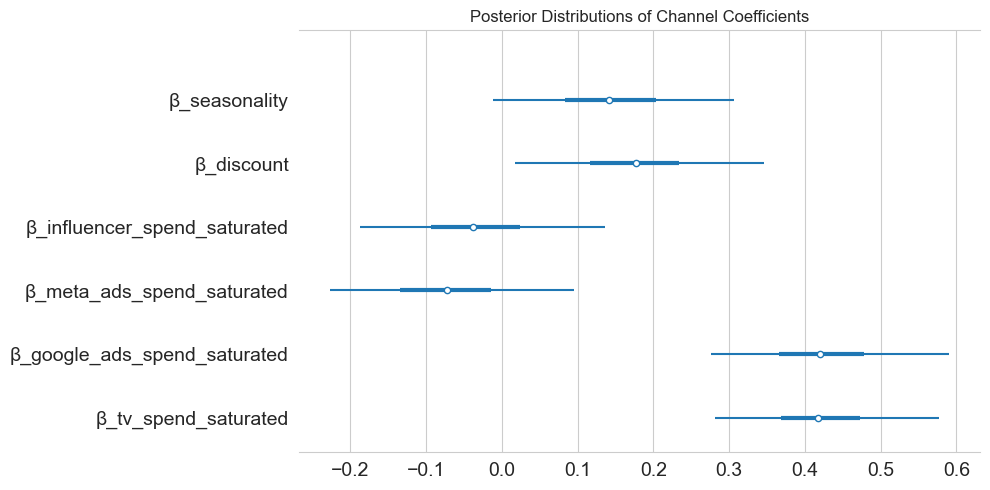

In [17]:
# forest plot — visual comparison of channel effects
az.plot_forest(trace, var_names=["betas"], combined=True, figsize=(10, 5))
plt.title("Posterior Distributions of Channel Coefficients")
ax = plt.gca()
ax.set_yticklabels([f"β_{n}" for n in feature_names])
plt.tight_layout()
plt.show()

                   channel  abs_contribution  pct_contribution
                  discount             37.91              34.9
               seasonality             37.91              34.9
google_ads_spend_saturated             14.61              13.4
        tv_spend_saturated              9.33               8.6
influencer_spend_saturated              5.97               5.5
  meta_ads_spend_saturated              2.92               2.7


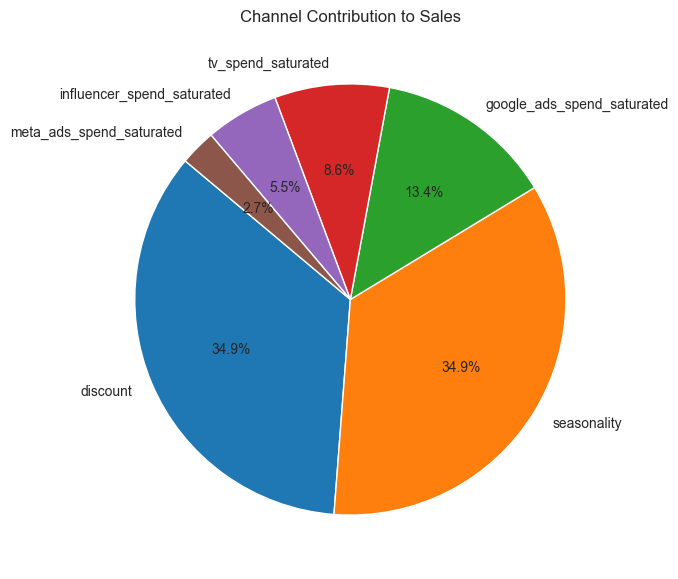

In [18]:
# ── Channel contributions ───────────────────────────────────────
beta_means = trace.posterior["betas"].mean(dim=["chain", "draw"]).values
alpha_mean = trace.posterior["alpha"].mean(dim=["chain", "draw"]).values.item()

# predicted sales
y_pred_scaled = alpha_mean + X_scaled @ beta_means
y_pred = y_pred_scaled * y_std + y_mean

# contribution of each feature (absolute scaled effect)
contributions = np.abs(X_scaled * beta_means)
total = contributions.sum(axis=0)
pct = (total / total.sum()) * 100

contrib_df = pd.DataFrame({
    "channel": feature_names,
    "abs_contribution": total.round(2),
    "pct_contribution": pct.round(1),
}).sort_values("pct_contribution", ascending=False)

print(contrib_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(contrib_df["pct_contribution"], labels=contrib_df["channel"],
       autopct="%1.1f%%", startangle=140)
ax.set_title("Channel Contribution to Sales")
plt.show()

         channel  total_spend  attributed_sales    ROI
influencer_spend       296460             15852 0.0535
google_ads_spend       997832             38802 0.0389
        tv_spend      1417199             24795 0.0175
  meta_ads_spend       662321              7756 0.0117


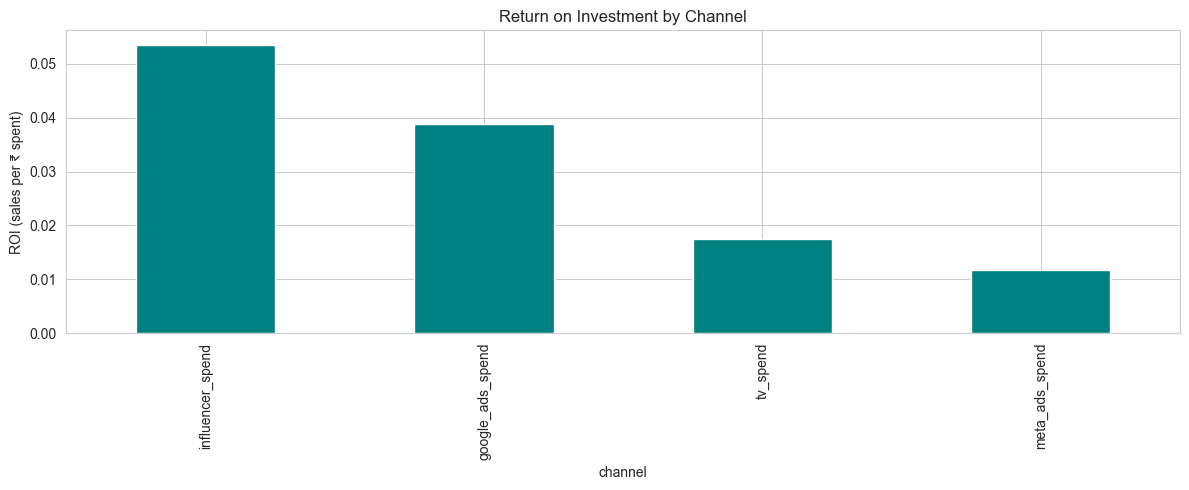

In [19]:
# ── ROI per channel ─────────────────────────────────────────────
roi_data = []
for i, col in enumerate(spend_cols):
    total_spend = df[col].sum()
    chan_contrib = np.abs(X_scaled[:, i] * beta_means[i]) * y_std
    total_sales_attr = chan_contrib.sum()
    roi = total_sales_attr / total_spend
    roi_data.append({
        "channel": col,
        "total_spend": round(total_spend),
        "attributed_sales": round(total_sales_attr),
        "ROI": round(roi, 4),
    })

roi_df = pd.DataFrame(roi_data).sort_values("ROI", ascending=False)
print(roi_df.to_string(index=False))

roi_df.plot.bar(x="channel", y="ROI", legend=False, color="teal")
plt.ylabel("ROI (sales per ₹ spent)")
plt.title("Return on Investment by Channel")
plt.tight_layout()
plt.show()

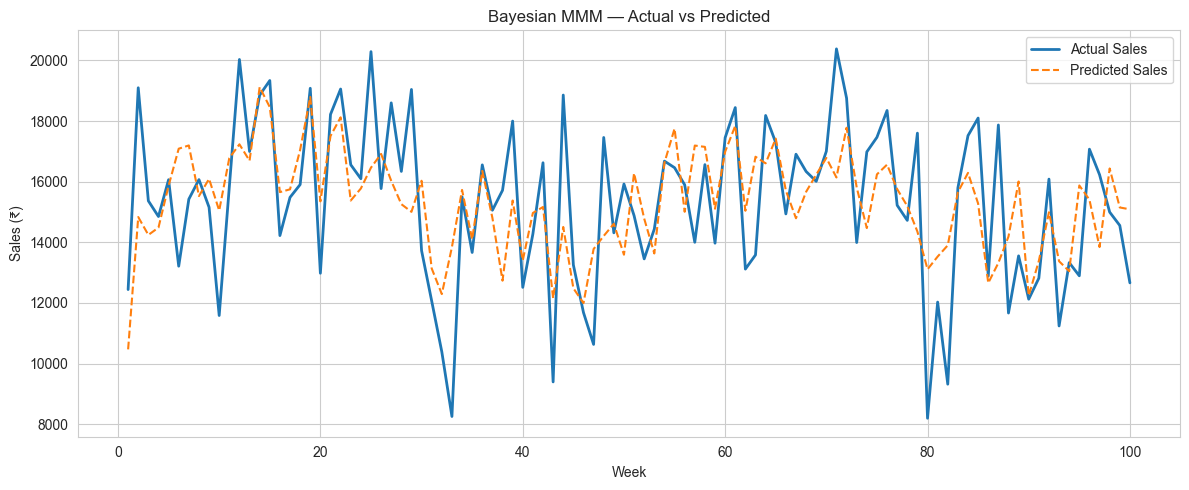

R²  = 0.3786
MAPE = 11.54%


In [20]:
# ── Actual vs Predicted ─────────────────────────────────────────
from sklearn.metrics import r2_score, mean_absolute_percentage_error

plt.figure(figsize=(12, 5))
plt.plot(df["week"], y, label="Actual Sales", linewidth=2)
plt.plot(df["week"], y_pred, label="Predicted Sales", linestyle="--")
plt.xlabel("Week")
plt.ylabel("Sales (₹)")
plt.title("Bayesian MMM — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

print(f"R²  = {r2_score(y, y_pred):.4f}")
print(f"MAPE = {mean_absolute_percentage_error(y, y_pred)*100:.2f}%")

---
## 5. Hyperparameter Optimization (Optuna)

Search for the best adstock decay and saturation alpha for each channel, instead of guessing manually.

In [21]:
# ── 5. Optuna hyperparameter search ────────────────────────────
import optuna
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def build_features(params, df):
    """Rebuild adstock + saturation features from raw spend."""
    features = pd.DataFrame()
    for col in spend_cols:
        decay = params[f"{col}_decay"]
        alpha_sat = params[f"{col}_alpha"]
        adstocked = adstock_transform(df[col], decay)
        features[col] = saturation_transform(pd.Series(adstocked), alpha_sat)
    features["discount"] = df["discount"].values
    features["seasonality"] = df["seasonality"].values
    return features

def objective(trial):
    params = {}
    for col in spend_cols:
        params[f"{col}_decay"] = trial.suggest_float(f"{col}_decay", 0.0, 0.9)
        params[f"{col}_alpha"] = trial.suggest_float(f"{col}_alpha", 1e-6, 5e-4, log=True)

    X_opt = build_features(params, df).values
    ridge = Ridge(alpha=1.0)
    scores = cross_val_score(ridge, X_opt, y, cv=5, scoring="r2")
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"\nBest CV R²: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.6f}")

Best trial: 197. Best value: 0.263914: 100%|██████████| 200/200 [00:05<00:00, 39.27it/s]


Best CV R²: 0.2639
Best params:
  tv_spend_decay: 0.002114
  tv_spend_alpha: 0.000079
  google_ads_spend_decay: 0.065384
  google_ads_spend_alpha: 0.000128
  meta_ads_spend_decay: 0.698330
  meta_ads_spend_alpha: 0.000002
  influencer_spend_decay: 0.662359
  influencer_spend_alpha: 0.000407


In [22]:
# rebuild features with optimised params
best_params = study.best_params
X_best = build_features(best_params, df).values

# quick Ridge sanity check
ridge = Ridge(alpha=1.0).fit(X_best, y)
y_pred_ridge = ridge.predict(X_best)
print(f"Ridge R² (optimised features): {r2_score(y, y_pred_ridge):.4f}")

# scale for PyMC
Xb_mean, Xb_std = X_best.mean(0), X_best.std(0)
Xb_scaled = (X_best - Xb_mean) / Xb_std

Ridge R² (optimised features): 0.3816


In [23]:
# refit Bayesian model with the optimised features
opt_feature_names = spend_cols + ["discount", "seasonality"]

with pm.Model() as mmm_opt:
    alpha_c = pm.Normal("alpha", mu=0, sigma=1)
    betas_c = pm.Normal("betas", mu=0, sigma=1, shape=Xb_scaled.shape[1])
    sigma_c = pm.HalfNormal("sigma", sigma=1)

    mu_c = alpha_c + pm.math.dot(Xb_scaled, betas_c)
    obs = pm.Normal("sales", mu=mu_c, sigma=sigma_c, observed=y_scaled)

    trace_opt = pm.sample(1000, tune=1000, cores=1, random_seed=42, progressbar=True)

summary_opt = az.summary(trace_opt, var_names=["betas", "alpha", "sigma"])
summary_opt.index = [f"beta_{n}" for n in opt_feature_names] + ["alpha", "sigma"]
print(summary_opt.round(3))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, betas, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 110 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


                        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_tv_spend          0.278  0.077   0.129    0.413      0.002    0.002   
beta_google_ads_spend  0.230  0.084   0.072    0.387      0.002    0.002   
beta_meta_ads_spend    0.016  0.083  -0.133    0.180      0.002    0.002   
beta_influencer_spend -0.046  0.084  -0.196    0.117      0.002    0.002   
beta_discount          0.484  0.082   0.336    0.642      0.002    0.002   
beta_seasonality       0.421  0.078   0.285    0.579      0.001    0.002   
alpha                 -0.001  0.077  -0.149    0.142      0.002    0.002   
sigma                  0.782  0.057   0.677    0.891      0.001    0.001   

                       ess_bulk  ess_tail  r_hat  
beta_tv_spend            2209.0    1492.0   1.00  
beta_google_ads_spend    2346.0    1527.0   1.01  
beta_meta_ads_spend      2128.0    1692.0   1.00  
beta_influencer_spend    1988.0    1525.0   1.00  
beta_discount            2380.0    1436.0   1.00  
beta_seas

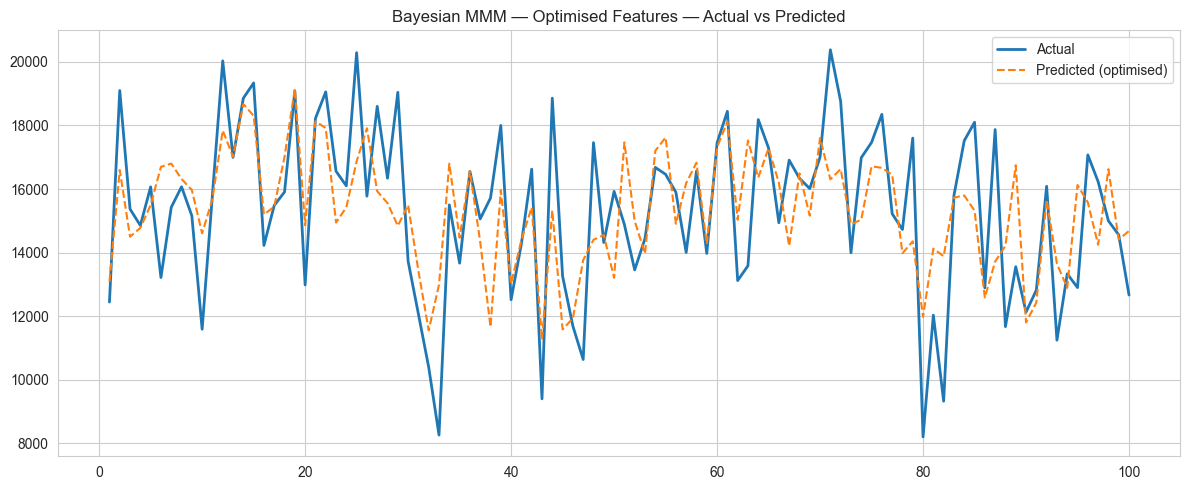

R²  = 0.4416
MAPE = 10.84%


In [24]:
# actual vs predicted with optimised features
beta_opt = trace_opt.posterior["betas"].mean(dim=["chain", "draw"]).values
alpha_opt = trace_opt.posterior["alpha"].mean(dim=["chain", "draw"]).values.item()
y_pred_opt_scaled = alpha_opt + Xb_scaled @ beta_opt
y_pred_opt = y_pred_opt_scaled * y_std + y_mean

plt.figure(figsize=(12, 5))
plt.plot(df["week"], y, label="Actual", linewidth=2)
plt.plot(df["week"], y_pred_opt, label="Predicted (optimised)", linestyle="--")
plt.title("Bayesian MMM — Optimised Features — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

print(f"R²  = {r2_score(y, y_pred_opt):.4f}")
print(f"MAPE = {mean_absolute_percentage_error(y, y_pred_opt)*100:.2f}%")

---
## 6. Budget Optimization Engine (SciPy)

Given a **fixed total budget**, find the channel allocation that **maximises predicted sales**.

In [25]:
# ── 6. Budget optimization with SciPy ──────────────────────────
from scipy.optimize import minimize

total_budget = df[spend_cols].sum(axis=1).mean()  # avg weekly total spend
print(f"Average weekly budget: ₹{total_budget:,.0f}")

def predict_sales(spend_array):
    """Raw spend per channel → predicted sales (negative for minimiser)."""
    features = []
    for i, col in enumerate(spend_cols):
        decay = best_params[f"{col}_decay"]
        alpha_sat = best_params[f"{col}_alpha"]
        # single-week estimate: adstock ≈ raw spend (no history context)
        sat = 1 - np.exp(-alpha_sat * spend_array[i])
        features.append(sat)

    features.append(df["discount"].median())   # hold discount at median
    features.append(df["seasonality"].median()) # hold seasonality at median
    features = np.array(features)

    features_scaled = (features - Xb_mean) / Xb_std
    pred_scaled = alpha_opt + features_scaled @ beta_opt
    pred = pred_scaled * y_std + y_mean
    return -pred  # negative because scipy minimises

# constraint: total spend = budget
constraints = {"type": "eq", "fun": lambda x: x.sum() - total_budget}
bounds = [(0, total_budget)] * len(spend_cols)
x0 = np.full(len(spend_cols), total_budget / len(spend_cols))

result = minimize(predict_sales, x0, method="SLSQP", bounds=bounds, constraints=constraints)

optimal_allocation = result.x
optimal_sales = -result.fun

print(f"\n── Optimal Budget Allocation (weekly ₹{total_budget:,.0f}) ──")
for col, alloc in zip(spend_cols, optimal_allocation):
    print(f"  {col:30s}: ₹{alloc:>10,.0f}  ({alloc/total_budget*100:.1f}%)")
print(f"\nPredicted sales: ₹{optimal_sales:,.0f}")

Average weekly budget: ₹33,738

── Optimal Budget Allocation (weekly ₹33,738) ──
  tv_spend                      : ₹    20,252  (60.0%)
  google_ads_spend              : ₹    13,486  (40.0%)
  meta_ads_spend                : ₹         0  (0.0%)
  influencer_spend              : ₹         0  (0.0%)

Predicted sales: ₹18,279


In [26]:
# compare current average vs optimal allocation
current_avg = df[spend_cols].mean().values
current_sales = -predict_sales(current_avg)

print("── Current vs Optimal ──")
print(f"{'Channel':<30} {'Current':>10} {'Optimal':>10} {'Δ':>10}")
print("-" * 62)
for i, col in enumerate(spend_cols):
    delta = optimal_allocation[i] - current_avg[i]
    print(f"{col:<30} ₹{current_avg[i]:>9,.0f} ₹{optimal_allocation[i]:>9,.0f} ₹{delta:>+9,.0f}")
print("-" * 62)
print(f"{'Predicted Sales':<30} ₹{current_sales:>9,.0f} ₹{optimal_sales:>9,.0f} ₹{optimal_sales-current_sales:>+9,.0f}")
pct_uplift = (optimal_sales - current_sales) / current_sales * 100
print(f"{'Uplift':<30} {'':>10} {'':>10} {pct_uplift:>+9.1f}%")

── Current vs Optimal ──
Channel                           Current    Optimal          Δ
--------------------------------------------------------------
tv_spend                       ₹   14,172 ₹   20,252 ₹   +6,080
google_ads_spend               ₹    9,978 ₹   13,486 ₹   +3,507
meta_ads_spend                 ₹    6,623 ₹        0 ₹   -6,623
influencer_spend               ₹    2,965 ₹        0 ₹   -2,965
--------------------------------------------------------------
Predicted Sales                ₹   15,343 ₹   18,279 ₹   +2,936
Uplift                                                   +19.1%


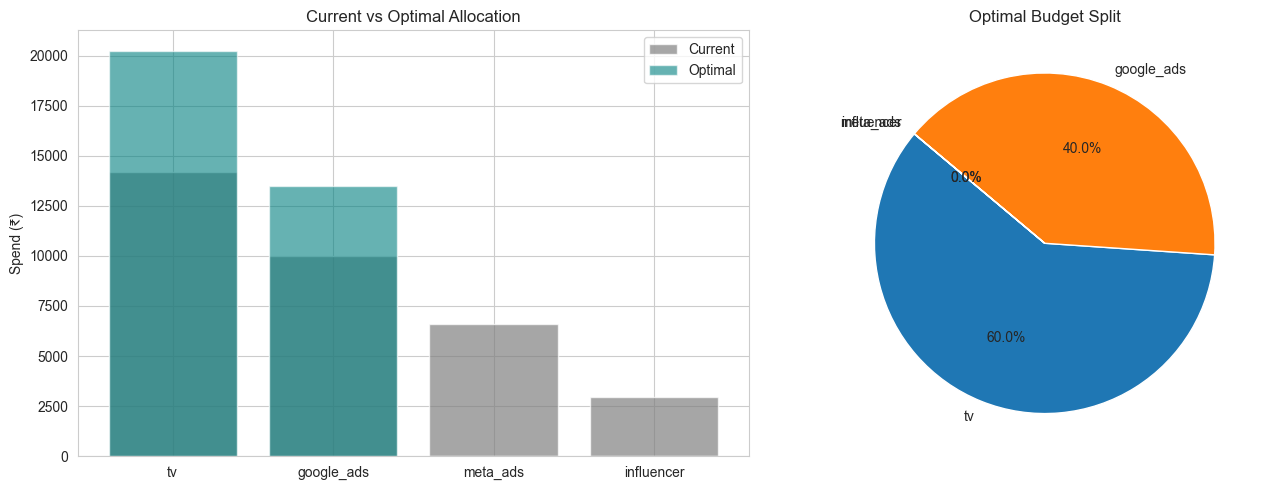

In [27]:
# visualise allocation comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [c.replace("_spend", "") for c in spend_cols]

axes[0].bar(labels, current_avg, color="gray", alpha=0.7, label="Current")
axes[0].bar(labels, optimal_allocation, color="teal", alpha=0.6, label="Optimal")
axes[0].set_ylabel("Spend (₹)")
axes[0].set_title("Current vs Optimal Allocation")
axes[0].legend()

axes[1].pie(optimal_allocation, labels=labels, autopct="%1.1f%%", startangle=140)
axes[1].set_title("Optimal Budget Split")

plt.tight_layout()
plt.show()

---
## 7. Counterfactual Simulation Engine

Ask **"what if"** questions: what happens to sales under different spend scenarios?

In [28]:
# ── 7. Counterfactual simulations ──────────────────────────────
def simulate_scenario(scenario_spend, label="Scenario"):
    """Given channel spends, predict sales."""
    spend = np.array([scenario_spend.get(c, df[c].mean()) for c in spend_cols])
    pred = -predict_sales(spend)
    return {"scenario": label, "predicted_sales": pred}

baseline_spend = {c: df[c].mean() for c in spend_cols}
baseline_sales = simulate_scenario(baseline_spend, "Baseline")["predicted_sales"]

# define what-if scenarios
scenarios = [
    ("Baseline", baseline_spend),
    ("Google Ads +30%", {**baseline_spend, "google_ads_spend": baseline_spend["google_ads_spend"] * 1.3}),
    ("TV Ads stop", {**baseline_spend, "tv_spend": 0}),
    ("Influencer 2x", {**baseline_spend, "influencer_spend": baseline_spend["influencer_spend"] * 2}),
    ("Meta Ads +50%", {**baseline_spend, "meta_ads_spend": baseline_spend["meta_ads_spend"] * 1.5}),
    ("All digital +20%", {
        **baseline_spend,
        "google_ads_spend": baseline_spend["google_ads_spend"] * 1.2,
        "meta_ads_spend": baseline_spend["meta_ads_spend"] * 1.2,
        "influencer_spend": baseline_spend["influencer_spend"] * 1.2,
    }),
    ("Slash all by 25%", {c: v * 0.75 for c, v in baseline_spend.items()}),
]

results = []
for name, spend_dict in scenarios:
    res = simulate_scenario(spend_dict, name)
    res["delta_sales"] = res["predicted_sales"] - baseline_sales
    res["delta_pct"] = (res["delta_sales"] / baseline_sales) * 100
    results.append(res)

sim_df = pd.DataFrame(results)
sim_df["predicted_sales"] = sim_df["predicted_sales"].round(0)
sim_df["delta_sales"] = sim_df["delta_sales"].round(0)
sim_df["delta_pct"] = sim_df["delta_pct"].round(2)
print(sim_df.to_string(index=False))

        scenario  predicted_sales  delta_sales  delta_pct
        Baseline          15343.0          0.0       0.00
 Google Ads +30%          15885.0        542.0       3.53
     TV Ads stop           9454.0      -5889.0     -38.38
   Influencer 2x          14952.0       -391.0      -2.55
   Meta Ads +50%          15379.0         37.0       0.24
All digital +20%          15622.0        279.0       1.82
Slash all by 25%          13959.0      -1384.0      -9.02


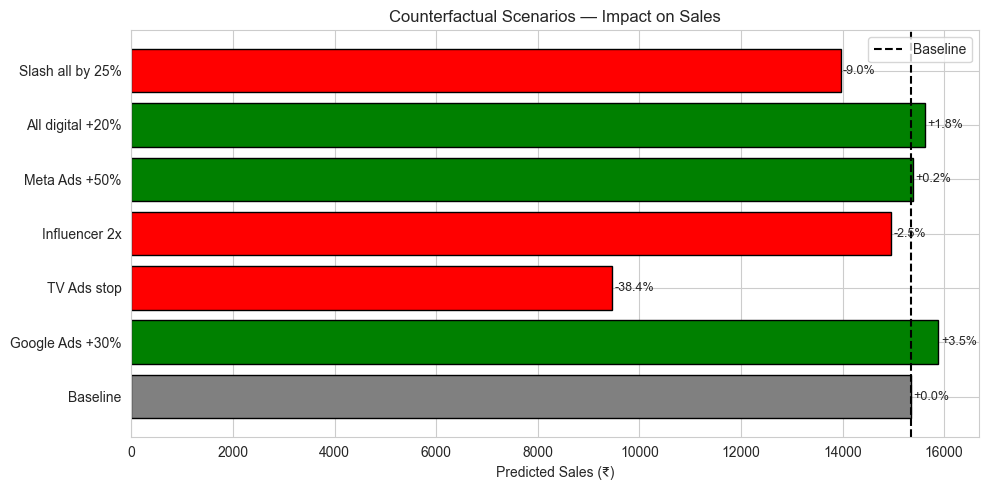

In [29]:
# visualise counterfactuals
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["gray" if s == "Baseline" else ("green" if d > 0 else "red")
          for s, d in zip(sim_df["scenario"], sim_df["delta_sales"])]

ax.barh(sim_df["scenario"], sim_df["predicted_sales"], color=colors, edgecolor="black")
ax.axvline(baseline_sales, color="black", linestyle="--", label="Baseline")
ax.set_xlabel("Predicted Sales (₹)")
ax.set_title("Counterfactual Scenarios — Impact on Sales")
ax.legend()

for i, (val, pct) in enumerate(zip(sim_df["predicted_sales"], sim_df["delta_pct"])):
    ax.text(val + 50, i, f"{pct:+.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

---
## Summary

| Step | What we did |
|------|-------------|
| 1. Data Ingestion | Loaded 100 weeks of marketing data |
| 2. Feature Engineering | Applied adstock (carry-over) + saturation (diminishing returns) transforms |
| 3. Causal Discovery | Used DoWhy to validate causal links between channels and sales |
| 4. Bayesian MMM | Fit PyMC model to estimate channel contributions with uncertainty |
| 5. Hyperparameter Tuning | Optuna searched best adstock decay & saturation params (200 trials) |
| 6. Budget Optimization | SciPy SLSQP found optimal spend allocation to max sales |
| 7. Counterfactual Sim | "What if" scenarios quantify impact of budget changes |